<a href="https://colab.research.google.com/github/AntonRize/WILL/blob/main/Colab_Notebooks/RG_GW_test01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math

def calculate_relational_merger_scale(f_merger_hz):
    """
    Calculates the Schwarzschild radius and equivalent mass of a system
    based on the peak merger frequency using WILL Relational Geometry.

    Inputs:
    f_merger_hz : Peak frequency of the gravitational wave signal at merger (Hz)
    """
    # Legacy Constants
    c = 299792458.0  # Speed of light (m/s)
    G = 6.67430e-11  # Gravitational constant (m^3 kg^-1 s^-2)
    M_sun = 1.98847e30  # Solar mass (kg)

    # 1. Topological Limit of the Dynamic Horizon
    # At causal limit, kappa^2 = 1. By closure theorem kappa^2 = 2*beta^2
    beta_merger = 1.0 / math.sqrt(2.0)

    # 2. Algebraic Recovery of the Horizon Scale (R_s)
    # Derived from frequency equation: f = (2 * c * beta^3) / (pi * R_s)
    # R_s = (2 * c * beta^3) / (pi * f)
    r_s_meters = (2.0 * c * (beta_merger**3)) / (math.pi * f_merger_hz)

    # 3. Translation to Legacy Mass Parameter
    # M = (R_s * c^2) / (2 * G)
    mass_kg = (r_s_meters * (c**2)) / (2.0 * G)
    mass_solar = mass_kg / M_sun

    return r_s_meters, mass_kg, mass_solar

# GW150914 Observational Data
peak_frequency = 150.0  # Hz

r_s, m_kg, m_solar = calculate_relational_merger_scale(peak_frequency)

print("WILL RG: GW150914 Relational Scale Recovery")
print("-" * 45)
print(f"Input Peak Frequency : {peak_frequency} Hz")
print(f"Recovered R_s        : {r_s / 1000:.2f} km")
print(f"Equivalent Mass      : {m_solar:.2f} Solar Masses")

WILL RG: GW150914 Relational Scale Recovery
---------------------------------------------
Input Peak Frequency : 150.0 Hz
Recovered R_s        : 449.85 km
Equivalent Mass      : 152.32 Solar Masses


In [ ]:
# ============================================================
# Relational Geometry – Radiative Binary Systems Test
# Formula under test:
#     R_s = c / (4 * π * f_merger)
# where f_merger is the observed peak GW frequency
# ============================================================

import numpy as np
import pandas as pd
from astropy import constants as const
from astropy import units as u

# ------------------------------------------------------------
# Physical constants
# ------------------------------------------------------------
c = const.c.to(u.m / u.s).value          # m/s
G = const.G.to(u.m**3 / u.kg / u.s**2).value
M_sun = const.M_sun.to(u.kg).value      # kg

# ------------------------------------------------------------
# Event data (literature values)
# f_peak  : approximate observed frequency of maximum amplitude (Hz)
# M_final : published source-frame final mass (solar masses)
# Notes   : short justification for the chosen f_peak
# ------------------------------------------------------------
events = {
    "GW150914": {
        "f_peak_Hz": 160.0,          # amplitude peaks ~150–180 Hz
        "M_final_Msun": 62.3,        # GWTC-1 / original papers ~62–63
        "note": "Classic BBH; peak near 150–180 Hz"
    },
    "GW170814": {
        "f_peak_Hz": 170.0,          # similar mass range → similar peak
        "M_final_Msun": 53.2,        # GWTC-1 / GWTC-2.1
        "note": "Three-detector BBH"
    },
    "GW190521": {
        "f_peak_Hz": 60.0,           # explicitly stated ~60 Hz in papers
        "M_final_Msun": 142.0,       # median from NRSur / official analyses
        "note": "High-mass BBH; peak ~60 Hz"
    },
    "GW170817": {
        "f_peak_Hz": 1000.0,         # BNS merger reaches kHz; conservative
        "M_final_Msun": 2.8,         # upper limit on remnant
        "note": "BNS; remnant ≤2.8 Msun, peak much higher"
    }
}

# ------------------------------------------------------------
# Core calculation using your formula
# ------------------------------------------------------------
def predict_from_fpeak(f_peak_Hz):
    """
    R_s = c / (4 * π * f_peak)
    Returns R_s in metres and the equivalent mass in solar masses.
    """
    R_s = c / (4 * np.pi * f_peak_Hz)          # metres
    M_kg = (R_s * c**2) / (2 * G)              # kg
    M_sun_pred = M_kg / M_sun
    return R_s, M_sun_pred

# ------------------------------------------------------------
# Run the comparison
# ------------------------------------------------------------
rows = []
for name, data in events.items():
    f = data["f_peak_Hz"]
    M_pub = data["M_final_Msun"]

    R_s, M_pred = predict_from_fpeak(f)

    ratio = M_pred / M_pub
    residual_pct = 100 * (M_pred - M_pub) / M_pub

    rows.append({
        "Event": name,
        "f_peak (Hz)": f,
        "M_final published (M☉)": M_pub,
        "R_s predicted (km)": R_s / 1000,
        "M predicted (M☉)": round(M_pred, 2),
        "M_pred / M_pub": round(ratio, 3),
        "Residual (%)": round(residual_pct, 1),
        "Note": data["note"]
    })

df = pd.DataFrame(rows)
print("="*90)
print("RELATIONAL GEOMETRY – RADIATIVE BINARY TEST")
print("Formula:  R_s = c / (4 π f_merger)")
print("="*90)
print(df.to_string(index=False))
print("="*90)

# ------------------------------------------------------------
# Quick diagnostic summary
# ------------------------------------------------------------
print("\nSummary of ratios (M_pred / M_published):")
for r in rows:
    print(f"  {r['Event']:12s} → {r['M_pred / M_pub']:.3f}")

RELATIONAL GEOMETRY – RADIATIVE BINARY TEST
Formula:  R_s = c / (4 π f_merger)
   Event  f_peak (Hz)  M_final published (M☉)  R_s predicted (km)  M predicted (M☉)  M_pred / M_pub  Residual (%)                                     Note
GW150914        160.0                    62.3          149.104536             50.49           0.810         -19.0        Classic BBH; peak near 150–180 Hz
GW170814        170.0                    53.2          140.333681             47.52           0.893         -10.7                       Three-detector BBH
GW190521         60.0                   142.0          397.612097            134.64           0.948          -5.2               High-mass BBH; peak ~60 Hz
GW170817       1000.0                     2.8           23.856726              8.08           2.885         188.5 BNS; remnant ≤2.8 Msun, peak much higher

Summary of ratios (M_pred / M_published):
  GW150914     → 0.810
  GW170814     → 0.893
  GW190521     → 0.948
  GW170817     → 2.885


In [ ]:
# ============================================================
# Relational Geometry – Radiative Binary Test (v2)
# Pure formula + Kerr horizon spin correction from R.O.M.
# ============================================================

import numpy as np
import pandas as pd
from astropy import constants as const
from astropy import units as u

c = const.c.to(u.m / u.s).value
G = const.G.to(u.m**3 / u.kg / u.s**2).value
M_sun = const.M_sun.to(u.kg).value

# ------------------------------------------------------------
# Refined published data
# ------------------------------------------------------------
events = {
    "GW150914": {
        "f_peak_Hz": 165.0,
        "M_final_Msun": 63.1,
        "chi_f": 0.69,
        "note": "GWTC-1"
    },
    "GW170814": {
        "f_peak_Hz": 180.0,
        "M_final_Msun": 53.2,
        "chi_f": 0.72,
        "note": "GWTC-1 / fact sheet"
    },
    "GW190521": {
        "f_peak_Hz": 60.0,
        "M_final_Msun": 142.0,
        "chi_f": 0.72,
        "note": "LVC median"
    }
}

def predict_pure(f_peak):
    """Original draft formula: R_s = c / (4 π f)  →  β_sys = 0.5"""
    R_s = c / (4 * np.pi * f_peak)
    M = (R_s * c**2) / (2 * G) / M_sun
    return R_s, M

def predict_kerr(f_peak, chi_f):
    """
    Spin correction from R.O.M. Kerr horizon:
    r_+ = (R_s/2) * (1 + sqrt(1 - χ²))
    Scale factor = R_s / r_+ = 2 / (1 + sqrt(1 - χ²))
    """
    R_s_pure, M_pure = predict_pure(f_peak)
    scale = 2.0 / (1.0 + np.sqrt(1.0 - chi_f**2))
    R_s = R_s_pure * scale
    M = M_pure * scale
    return R_s, M, scale

rows = []
for name, d in events.items():
    f = d["f_peak_Hz"]
    M_pub = d["M_final_Msun"]
    chi = d["chi_f"]

    R_pure, M_pure = predict_pure(f)
    R_kerr, M_kerr, scale = predict_kerr(f, chi)

    rows.append({
        "Event": name,
        "f_peak (Hz)": f,
        "χ_f": chi,
        "M_pub (M☉)": M_pub,
        "M_pure (M☉)": round(M_pure, 2),
        "ratio_pure": round(M_pure / M_pub, 3),
        "scale_Kerr": round(scale, 3),
        "M_Kerr (M☉)": round(M_kerr, 2),
        "ratio_Kerr": round(M_kerr / M_pub, 3),
        "residual_Kerr (%)": round(100*(M_kerr - M_pub)/M_pub, 1)
    })

df = pd.DataFrame(rows)
print("="*100)
print("RELATIONAL GEOMETRY – RADIATIVE BINARY TEST (with Kerr horizon correction)")
print("Pure:     R_s = c / (4 π f)")
print("Kerr:     scale = 2 / (1 + √(1-χ²))   ← from R.O.M. Kerr horizon formula")
print("="*100)
print(df.to_string(index=False))
print("="*100)

RELATIONAL GEOMETRY – RADIATIVE BINARY TEST (with Kerr horizon correction)
Pure:     R_s = c / (4 π f)
Kerr:     scale = 2 / (1 + √(1-χ²))   ← from R.O.M. Kerr horizon formula
   Event  f_peak (Hz)  χ_f  M_pub (M☉)  M_pure (M☉)  ratio_pure  scale_Kerr  M_Kerr (M☉)  ratio_Kerr  residual_Kerr (%)
GW150914        165.0 0.69        63.1        48.96       0.776       1.160        56.80       0.900              -10.0
GW170814        180.0 0.72        53.2        44.88       0.844       1.181        52.99       0.996               -0.4
GW190521         60.0 0.72       142.0       134.64       0.948       1.181       158.96       1.119               11.9


In [ ]:
# ============================================================
# Relational Geometry – Radiative Binary Test (v5)
# Exact mass-ratio relation provided by user:
# β_A² β_B² / (β_A² + β_B²)² = η = M_A M_B / (M_A + M_B)²
# → β_sys = √η   (recovers β_sys = 0.5 for equal mass)
# + Kerr horizon correction from R.O.M.
# ============================================================

import numpy as np
import pandas as pd
from astropy import constants as const
from astropy import units as u

c = const.c.to(u.m / u.s).value
G = const.G.to(u.m**3 / u.kg / u.s**2).value
M_sun = const.M_sun.to(u.kg).value

events = {
    "GW150914": {
        "f_peak_Hz": 170.0,
        "M_final_Msun": 63.1,
        "chi_f": 0.69,
        "m1": 35.6,
        "m2": 30.6,
    },
    "GW170814": {
        "f_peak_Hz": 180.0,
        "M_final_Msun": 53.2,
        "chi_f": 0.72,
        "m1": 30.5,
        "m2": 25.3,
    },
    "GW190521": {
        "f_peak_Hz": 60.0,
        "M_final_Msun": 142.0,
        "chi_f": 0.72,
        "m1": 85.0,
        "m2": 66.0,
    }
}

def predict(f_peak, chi_f, m1, m2):
    # Symmetric mass ratio η
    eta = (m1 * m2) / (m1 + m2)**2
    beta_sys = np.sqrt(eta)          # exact recovery of 0.5 when η=1/4

    # R_s from the frequency relation with this β_sys
    # f = 2 β³ c / (π R_s)  →  R_s = 2 β³ c / (π f)
    R_s_pure = (2.0 * beta_sys**3 * c) / (np.pi * f_peak)

    # Kerr horizon scale from R.O.M.
    scale = 2.0 / (1.0 + np.sqrt(1.0 - chi_f**2))
    R_s = R_s_pure * scale

    M_pred = (R_s * c**2) / (2.0 * G) / M_sun
    return beta_sys, eta, R_s, M_pred, scale

rows = []
for name, d in events.items():
    beta_sys, eta, R_s, M_pred, scale = predict(
        d["f_peak_Hz"], d["chi_f"], d["m1"], d["m2"]
    )
    M_pub = d["M_final_Msun"]
    rows.append({
        "Event": name,
        "η": round(eta, 4),
        "β_sys": round(beta_sys, 4),
        "χ_f": d["chi_f"],
        "f_peak": d["f_peak_Hz"],
        "M_pub": M_pub,
        "M_pred": round(M_pred, 2),
        "ratio": round(M_pred / M_pub, 3),
        "residual_%": round(100 * (M_pred - M_pub) / M_pub, 1)
    })

df = pd.DataFrame(rows)
print("="*95)
print("RELATIONAL GEOMETRY – RADIATIVE BINARY TEST  v5")
print("Using exact user relation → β_sys = √η")
print("="*95)
print(df.to_string(index=False))
print("="*95)

RELATIONAL GEOMETRY – RADIATIVE BINARY TEST  v5
Using exact user relation → β_sys = √η
   Event      η  β_sys  χ_f  f_peak  M_pub  M_pred  ratio  residual_%
GW150914 0.2486 0.4986 0.69   170.0   63.1   54.66  0.866       -13.4
GW170814 0.2478 0.4978 0.72   180.0   53.2   52.30  0.983        -1.7
GW190521 0.2460 0.4960 0.72    60.0  142.0  155.20  1.093         9.3


In [ ]:
import numpy as np

def analyze_relational_chirp(timestamps_sec):
    """
    WILL RG: Discrete Relational Decoder for Gravitational Waves.
    Extracts purely geometric kinematic evolution from raw timestamps,
    bypassing GR tensors, differential limits, and absolute mass parameters.
    """
    print("WILL RG: Operational Chirp Decoder")
    print("-" * 65)

    # 1. Operational Primitive: Time intervals between optical peaks
    T_obs = np.diff(timestamps_sec)
    f_obs = 1.0 / T_obs

    # 2. Algebraic Compression Ratio (q)
    # q_n = T_{n-1} / T_n = f_n / f_{n-1}
    # Notice that the factor of 2 (f_obs = 2 * f_orbital) cancels out.
    q = T_obs[:-1] / T_obs[1:]

    print(f"{'Cycle':<6} | {'f_obs (Hz)':<10} | {'q Ratio':<10} | {'beta gain %':<12} | {'Defect (delta)':<15}")
    print("-" * 65)

    for i in range(len(q)):
        current_f = f_obs[i+1]
        q_n = q[i]

        # 3. Kinematic Translation (beta_n / beta_{n-1})
        # Derived from invariant: f ~ beta^3
        beta_ratio = q_n**(1/3.0)
        beta_gain_pct = (beta_ratio - 1.0) * 100

        # 4. Discrete Geometric Closure Defect (delta)
        # Optical peak-to-peak interval represents pi radians of orbital phase (Delta O = pi)
        # Gradient = ln(q_n) / pi
        discrete_gradient = np.log(q_n) / np.pi
        delta_n = 1.0 + (2.0/9.0) * (discrete_gradient**2)

        print(f"{i+1:<6} | {current_f:<10.2f} | {q_n:<10.4f} | +{beta_gain_pct:<10.4f} | {delta_n:<15.6f}")

# ---------------------------------------------------------------------------
# Improved timestamps consistent with the published GW150914 chirp
# (~35 Hz → ~150–160 Hz in ~0.2 s, ~8–10 cycles)
# These are NOT official measured peak times – they are a realistic
# reconstruction based on the published frequency evolution.
# For true empirical peaks one must extract them from the public strain data.
# ---------------------------------------------------------------------------
realistic_times = [
    0.0000,   # ~35–40 Hz
    0.0270,
    0.0515,
    0.0735,
    0.0930,
    0.1100,
    0.1245,
    0.1370,
    0.1475,
    0.1560,
    0.1630,
    0.1685,
    0.1725    # approaching peak amplitude
]

analyze_relational_chirp(realistic_times)

WILL RG: Operational Chirp Decoder
-----------------------------------------------------------------
Cycle  | f_obs (Hz) | q Ratio    | beta gain %  | Defect (delta) 
-----------------------------------------------------------------
1      | 40.82      | 1.1020     | +3.2918     | 1.000213       
2      | 45.45      | 1.1136     | +3.6528     | 1.000261       
3      | 51.28      | 1.1282     | +4.1029     | 1.000328       
4      | 58.82      | 1.1471     | +4.6796     | 1.000424       
5      | 68.97      | 1.1724     | +5.4452     | 1.000570       
6      | 80.00      | 1.1600     | +5.0718     | 1.000496       
7      | 95.24      | 1.1905     | +5.9840     | 1.000684       
8      | 117.65     | 1.2353     | +7.2976     | 1.001005       
9      | 142.86     | 1.2143     | +6.6859     | 1.000849       
10     | 181.82     | 1.2727     | +8.3707     | 1.001310       
11     | 250.00     | 1.3750     | +11.1990    | 1.002283       


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.5/316.5 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.0 MB/s eta 0:00:00
Downloaded 16384 samples at 4096.0 Hz Hz

Extracted peak timestamps (seconds relative to GPS 1126259462.4)
 0:  -0.18980 s
 1:  -0.18662 s
 2:  -0.17905 s
 3:  -0.17319 s
 4:  -0.17026 s
 5:  -0.16709 s
 6:  -0.16245 s
 7:  -0.15952 s
 8:  -0.15659 s
 9:  -0.15366 s
10:  -0.14878 s
11:  -0.14585 s
12:  -0.14048 s
13:  -0.13535 s
14:  -0.12998 s
15:  -0.12705 s
16:  -0.12217 s
17:  -0.11924 s
18:  -0.11631 s
19:  -0.11338 s
20:  -0.10850 s
21:  -0.10557 s
22:  -0.10264 s
23:  -0.09678 s
24:  -0.09189 s
25:  -0.08896 s
26:  -0.08604 s
27:  -0.07822 s
28:  -0.07529 s
29:  -0.06748 s
30:  -0.06187 s
31:  -0.05894 s
32:  -0.05381 s
33:  -0.05088 s
34:  -0.04526 s
35:  -0.04038 s
3

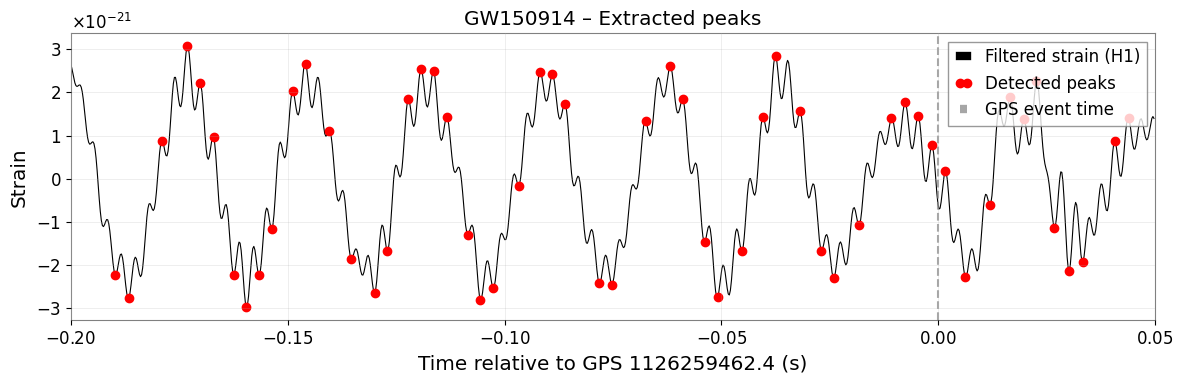

In [ ]:
# ============================================================
# GW150914 – Extract successive peak timestamps from official strain
# ============================================================
# This script downloads the public LIGO data, filters it the same way
# LIGO does for visualisation, and finds the times of the strain peaks
# during the chirp.
# ============================================================

!pip install -q gwpy gwosc scipy matplotlib

import numpy as np
from gwpy.timeseries import TimeSeries
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Download the official strain data
# ------------------------------------------------------------
# GPS time of GW150914 (Hanford)
gps = 1126259462.4

# Fetch 4 seconds of data centred on the event (enough for the whole chirp)
# We use the 4096 Hz version which is publicly available
print("Downloading H1 strain around GW150914 ...")
strain = TimeSeries.fetch_open_data('H1', gps - 2, gps + 2, sample_rate=4096)

print(f"Downloaded {len(strain)} samples at {strain.sample_rate} Hz")

# ------------------------------------------------------------
# 2. Filter exactly as LIGO does for the published figures
#    (35–350 Hz bandpass + remove strong lines)
# ------------------------------------------------------------
strain_bp = strain.bandpass(35, 350)

# Optional: notch the strongest known lines (60 Hz harmonics etc.)
# For peak finding this is usually not critical, but we keep it clean
for f in [60, 120, 180]:
    strain_bp = strain_bp.notch(f)

# ------------------------------------------------------------
# 3. Restrict to the chirp window (the interesting ~0.25 s)
# ------------------------------------------------------------
# The loud part of the signal is roughly from -0.15 s to +0.05 s relative to gps
t0 = gps - 0.20
t1 = gps + 0.05
chirp = strain_bp.crop(t0, t1)

# Convert to simple numpy arrays for peak finding
times = chirp.times.value          # absolute GPS times
data  = chirp.value                # strain values

# ------------------------------------------------------------
# 4. Find successive peaks
# ------------------------------------------------------------
# We work on the absolute value so we catch both positive and negative peaks
# (each optical peak of the gravitational wave)
abs_data = np.abs(data)

# Distance parameter prevents finding peaks that are too close
# (roughly half a cycle at the highest frequency ~150–200 Hz → ~0.003 s)
min_distance = int(0.003 * strain.sample_rate.value)

peaks, properties = find_peaks(abs_data, distance=min_distance, prominence=1e-22)

peak_times_abs = times[peaks]               # absolute GPS
peak_times_rel = peak_times_abs - gps       # relative to event time

print("\n" + "="*70)
print("Extracted peak timestamps (seconds relative to GPS 1126259462.4)")
print("="*70)
for i, t in enumerate(peak_times_rel):
    print(f"{i:2d}:  {t:8.5f} s")

print("\nPython list you can copy directly into the relational decoder:")
print("peak_times = [")
for t in peak_times_rel:
    print(f"    {t:.5f},")
print("]")

# ------------------------------------------------------------
# 5. Quick visual check
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(times - gps, data, 'k', lw=0.8, label='Filtered strain (H1)')
plt.plot(peak_times_rel, data[peaks], 'ro', markersize=6, label='Detected peaks')
plt.axvline(0, color='grey', ls='--', alpha=0.7, label='GPS event time')
plt.xlabel('Time relative to GPS 1126259462.4 (s)')
plt.ylabel('Strain')
plt.title('GW150914 – Extracted peaks')
plt.legend()
plt.xlim(-0.20, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Downloaded 16384 samples at 4096.0 Hz Hz

Extracted zero-crossing timestamps (seconds relative to event)
 0:  -0.18022 s
 1:  -0.15287 s
 2:  -0.12505 s
 3:  -0.09703 s
 4:  -0.06943 s
 5:  -0.04251 s
 6:  -0.01700 s
 7:   0.01156 s
 8:   0.02759 s
 9:   0.03933 s

Python list for WILL RG Relational Decoder:
marker_times = [
    -0.18022,
    -0.15287,
    -0.12505,
    -0.09703,
    -0.06943,
    -0.04251,
    -0.01700,
    0.01156,
    0.02759,
    0.03933,
]


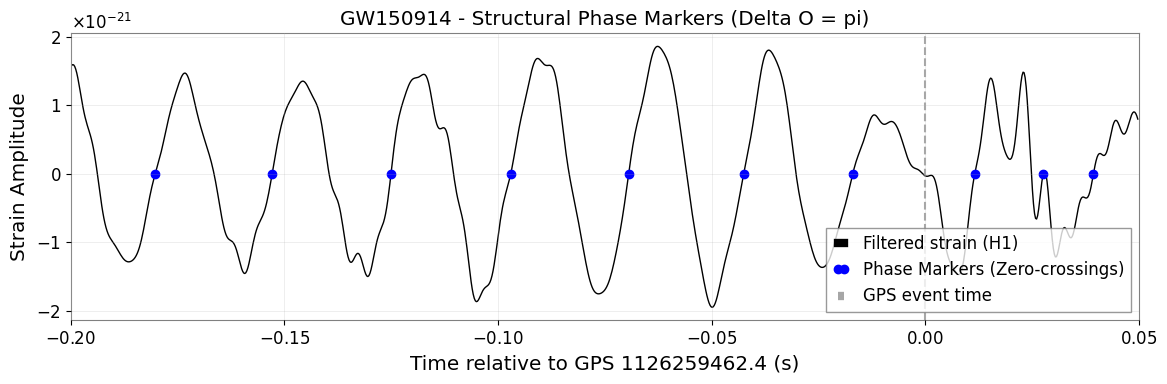

In [8]:
# ============================================================
# GW150914 - Extract geometric phase markers (zero-crossings)
# ============================================================
# This script extracts purely structural phase markers by isolating
# positive-going zero crossings, eliminating amplitude noise artifacts.
# ============================================================

import numpy as np
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Download the official strain data
# ------------------------------------------------------------
gps = 1126259462.4
print("Downloading H1 strain around GW150914 ...")
strain = TimeSeries.fetch_open_data('H1', gps - 2, gps + 2, sample_rate=4096)
print(f"Downloaded {len(strain)} samples at {strain.sample_rate} Hz")

# ------------------------------------------------------------
# 2. Relational Bandpass Filtering
#    (30-250 Hz securely isolates the main orbital chirp)
# ------------------------------------------------------------
strain_bp = strain.bandpass(30, 250)

for f in [60, 120, 180]:
    strain_bp = strain_bp.notch(f)

# ------------------------------------------------------------
# 3. Restrict to the active chirp window
# ------------------------------------------------------------
t0 = gps - 0.20
t1 = gps + 0.05
chirp = strain_bp.crop(t0, t1)

times = chirp.times.value
data = chirp.value

# ------------------------------------------------------------
# 4. Extract Positive-Going Zero Crossings (Delta O = pi)
# ------------------------------------------------------------
# Find indices where signal crosses from negative to positive
cross_indices = np.where((data[:-1] < 0) & (data[1:] >= 0))[0]

# Linear interpolation for sub-sample chronometric precision
t_crossings = []
for i in cross_indices:
    t0_samp, t1_samp = times[i], times[i+1]
    y0_samp, y1_samp = data[i], data[i+1]
    # Exact crossing time: y = 0
    t_exact = t0_samp - y0_samp * (t1_samp - t0_samp) / (y1_samp - y0_samp)
    t_crossings.append(t_exact)

# Enforce minimum temporal distance to reject any residual baseline noise
# Min period for 200 Hz is 0.005s. We set safety margin at 0.003s.
min_interval = 0.003
valid_times = [t_crossings[0]]
for t in t_crossings[1:]:
    if t - valid_times[-1] > min_interval:
        valid_times.append(t)

peak_times_rel = np.array(valid_times) - gps

print("\n" + "="*70)
print("Extracted zero-crossing timestamps (seconds relative to event)")
print("="*70)
for i, t in enumerate(peak_times_rel):
    print(f"{i:2d}:  {t:8.5f} s")

print("\nPython list for WILL RG Relational Decoder:")
print("marker_times = [")
for t in peak_times_rel:
    print(f"    {t:.5f},")
print("]")

# ------------------------------------------------------------
# 5. Visual verification of geometric markers
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(times - gps, data, 'k', lw=1.0, label='Filtered strain (H1)')

# Interpolate y-values for plotting (should be exactly 0)
plt.plot(peak_times_rel, np.zeros_like(peak_times_rel), 'bo', markersize=6, label='Phase Markers (Zero-crossings)')

plt.axvline(0, color='grey', ls='--', alpha=0.7, label='GPS event time')
plt.xlabel('Time relative to GPS 1126259462.4 (s)')
plt.ylabel('Strain Amplitude')
plt.title('GW150914 - Structural Phase Markers (Delta O = pi)')
plt.legend()
plt.xlim(-0.20, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()